Then under the hood, this is equivalent to:

python
Copy
Edit
# Instead of 10 one-hot vectors @ W1
embedding_output = W1[X]  # Lookup!
So:

Input shape: (batch_size, sequence_length) → (1, 10)

Output shape: (batch_size, sequence_length, embedding_dim) → (1, 10, embedding_dim)

No one-hot needed — Keras uses index-based lookup, which is way faster and memory-efficient



---

keras.datasets.imdb.load_data(
    path="imdb.npz",
    num_words=None,
    skip_top=0,
    maxlen=None,
    seed=113,
    start_char=1,
    oov_char=2,
    index_from=3,
    **kwargs
)- num_word by default is 10000

In [ ]:
from tensorflow.keras.datasets import imdb

In [ ]:
imdb_dataset= imdb.load_data(num_words= 10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
imdb_dataset

((array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
         list([1, 194, 1153, 194, 8255, 78, 

In [ ]:
(X_train,y_train),(x_test,y_test )= imdb_dataset

In [ ]:
y_train[0]

np.int64(1)

In [ ]:
word_to_index= imdb.get_word_index()

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


 these are the most common words in order of frequency.
The dataset is built so that:

Lower index = more frequent word

Higher index = less frequent word

For example:

In [ ]:
word_to_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [ ]:
index_to_word= {value:key for key, value in word_to_index.items()}

In [ ]:
index_to_word

{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [ ]:
X_train[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

Works only if you remember that Keras offsets real word indices by 3

Why? Because when you load IMDb with keras.datasets.imdb, the first few token IDs are reserved:


Token	ID
<PAD>	0
<START>	1
<UNK>	2
<UNUSED>	3
So the actual words start from index 4 onwards in the dataset, but the raw get_word_index() maps "the" → 1, "and" → 2, etc.

That's why we adjust the index by -3 when decoding. ✅



In [ ]:
decoded_string = " ".join(index_to_word.get(index-3,'?') for index in X_train[0])

In [ ]:
index_to_word[12118]

"'n"

In [ ]:
decoded_string

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

In [ ]:
decoded_string = " ".join(index_to_word[index] for index in X_train[0])

In [ ]:
decoded_string

"the as you with out themselves powerful lets loves their becomes reaching had journalist of lot from anyone to have after out atmosphere never more room and it so heart shows to years of every never going and help moments or of every chest visual movie except her was several of enough more with is now current film as you of mine potentially unfortunately of you than him that with out themselves her get for was camp of you movie sometimes movie that with scary but and to story wonderful that in seeing in character to of 70s musicians with heart had shadows they of here that with her serious to have does when from why what have critics they is you that isn't one will very to as itself with other and in of seen over landed for anyone of and br show's to whether from than out themselves history he name half some br of and odd was two most of mean for 1 any an boat she he should is thought frog but of script you not while history he heart to real at barrel but when from one bit then have t

Embedding layer

In [ ]:
from tensorflow.keras.preprocessing import sequence

In [ ]:

max_length = 500

X_train = sequence.pad_sequences(X_train, maxlen=max_length)
x_test = sequence.pad_sequences(x_test, maxlen=max_length)


In [ ]:
X_train.max()

np.int32(9999)

In [ ]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Embedding
from tensorflow.keras.models import Sequential

In [ ]:
vocab_size=10000

In [ ]:
model= Sequential()

In [ ]:
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length = max_length))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import tensorflow

In [ ]:
optimizer = tensorflow.keras.optimizers.Adam(learning_rate = 1e-4,clipnorm=1.0)

In [ ]:
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras import regularizers

In [ ]:
model.add(SimpleRNN(128, activation = "relu", kernel_regularizer=regularizers.l1_l2(0.0001), recurrent_regularizer=regularizers.l1_l2(0.0001)))
model.add(Dense(1, activation = "sigmoid"))


In [ ]:
model.compile(optimizer=optimizer, loss="binary_crossentropy" , metrics=["accuracy"])

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
early_stopping = EarlyStopping(monitor="val_loss", patience = 5, restore_best_weights=True)

The loss values was coming out to be nan because of gradient overexploding. to fix this:

I initiallized the learning rate to 1e-4 for the optimizer(which is used for calculating the gradient)

and  add regulizer

In [ ]:
model.fit(X_train,y_train, validation_split=0.2,batch_size=32, epochs = 10,callbacks=[early_stopping] )

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 160s 251ms/step - accuracy: 0.5426 - loss: 0.9122 - val_accuracy: 0.6608 - val_loss: 0.7973
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 260ms/step - accuracy: 0.7737 - loss: 0.9174 - val_accuracy: 0.8586 - val_loss: 0.7675
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 196s 250ms/step - accuracy: 0.8769 - loss: 0.9209 - val_accuracy: 0.8688 - val_loss: 0.4872
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 203s 252ms/step - accuracy: 0.9028 - loss: 56.5517 - val_accuracy: 0.8724 - val_loss: 0.4788
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 201s 250ms/step - accuracy: 0.9106 - loss: 119.8363 - val_accuracy: 0.8690 - val_loss: 0.7297
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 161s 257ms/step - accuracy: 0.9192 - loss: 48271200256.0000 - val_accuracy: 0.8668 - val_loss: 1.2413
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 154s 246ms/step - accuracy: 0.9197 - loss: 3127733429207040.0000 - val_accuracy: 0.8456 - val_loss: 721407.8750
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 206

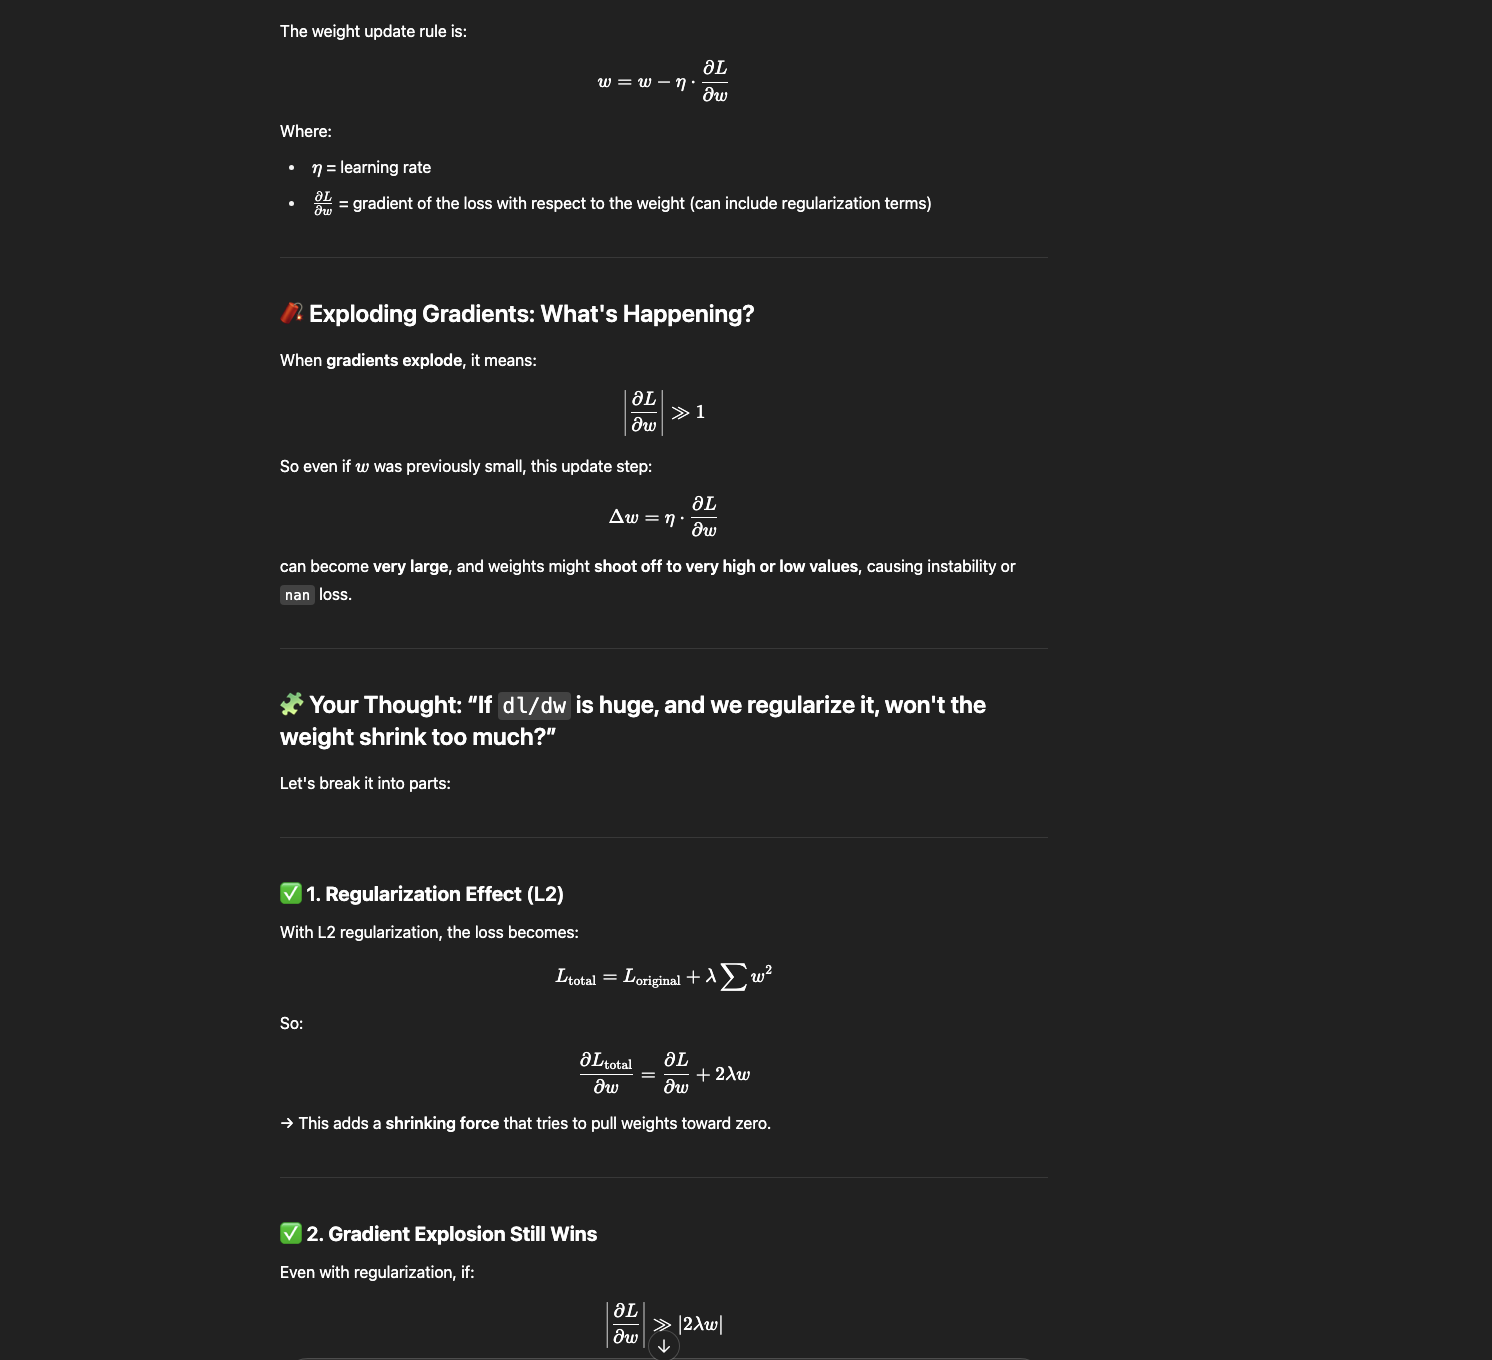

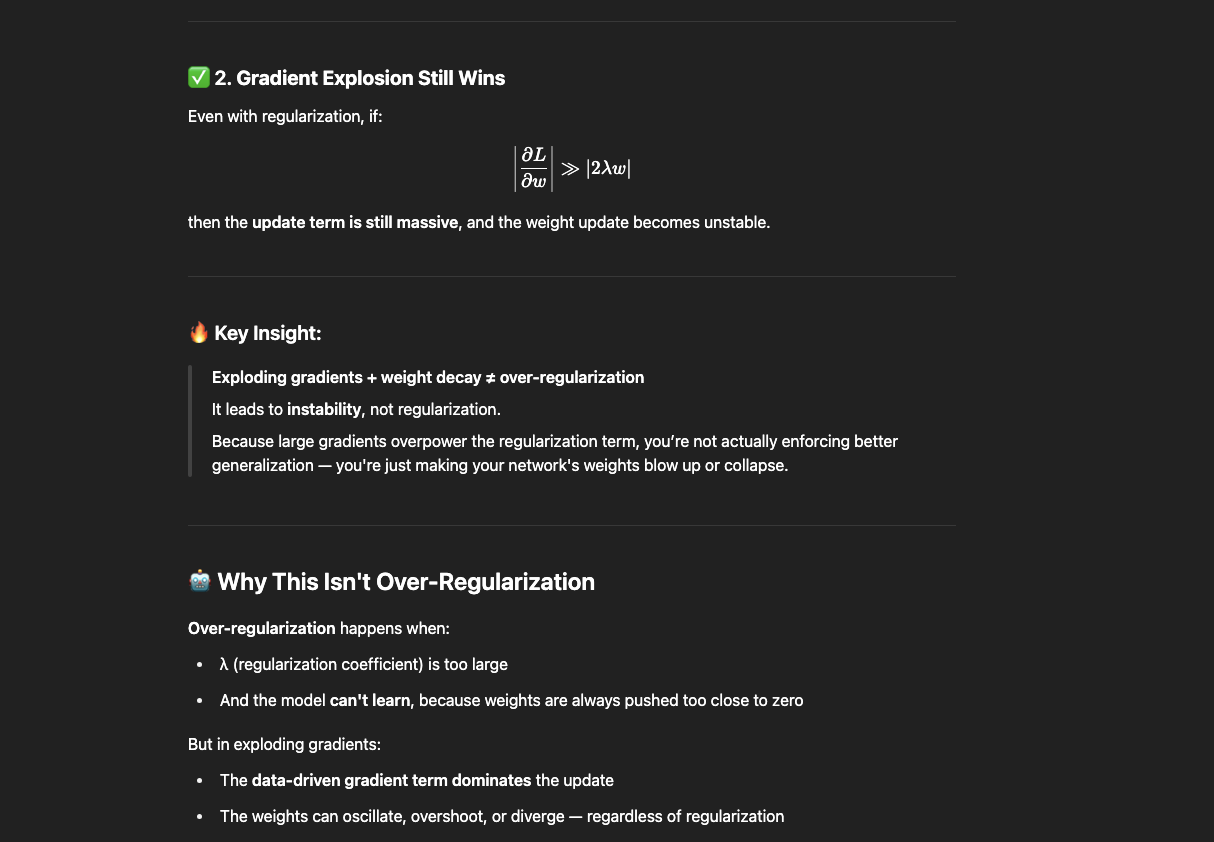



---


why gradient explode in Rnn

✅ Let’s Understand Why Gradients Can Still Explode in RNNs (even with binary cross-entropy)
⚠️ 1. Long Sequences + Recurrent Multiplication
In RNNs, gradients are multiplied across time steps during Backpropagation Through Time (BPTT):
because of chain rule
​

That product of Jacobians can grow rapidly → even if the loss per timestep is small (like binary cross-entropy).

👉 So even if individual gradients seem harmless, the recursive multiplication can still cause exploding gradients.



In [ ]:
model.save("model_simple_rnn.h5")